In [4]:
# ========================= START OF NOTEBOOK CODE =========================
# STEP 1 — Imports / Setup

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 80)

In [6]:
# STEP 2 — Configuration

CSV_PATH = "Electric_Vehicle_Charging_Station_Data.csv"

DATETIME_START = "Start_Date___Time"
DATETIME_END   = "End_Date___Time"
ENERGY_COL     = "Energy__kWh_"

# Output time series frequency
RESAMPLE_FREQ = "h"  # hourly

# ADF settings
ADF_REGRESSION = "c"
ADF_AUTOLAG    = None
MAXLAG = 48

# Seasonal lags to inspect in ADF/ACF/PACF
SEASONAL_LAGS = [24, 168]  # daily, weekly

# ACF/PACF plotting
NLAGS = 200  # must be >=168 to see weekly
CHECK_LAGS = [24, 168]

In [7]:
# STEP 3 — Load CSV + Basic cleaning (timestamps + energy validity)

with tqdm(total=6, desc="STEP 3: Load + clean sessions", unit="step") as pbar:
    df_raw = pd.read_csv(CSV_PATH)
    df = df_raw.copy()
    pbar.update(1)

    # Parse datetimes
    df[DATETIME_START] = pd.to_datetime(df[DATETIME_START], errors="coerce")
    df[DATETIME_END]   = pd.to_datetime(df[DATETIME_END], errors="coerce")
    pbar.update(1)

    # Drop missing timestamps
    df = df.dropna(subset=[DATETIME_START, DATETIME_END])
    pbar.update(1)

    # Numeric energy
    df[ENERGY_COL] = pd.to_numeric(df[ENERGY_COL], errors="coerce")
    df = df.dropna(subset=[ENERGY_COL])
    pbar.update(1)

    # Remove non-positive energy and invalid end<start
    df = df[df[ENERGY_COL] > 0]
    df = df[df[DATETIME_END] > df[DATETIME_START]]  # strictly > to avoid zero duration
    pbar.update(1)

    # Sort
    df = df.sort_values(DATETIME_START).reset_index(drop=True)
    pbar.update(1)

print("Clean session rows:", len(df))
df[[DATETIME_START, DATETIME_END, ENERGY_COL]].head()

STEP 3: Load + clean sessions:   0%|          | 0/6 [00:00<?, ?step/s]

Clean session rows: 131965


,Start_Date___Time,End_Date___Time,Energy__kWh_
0,2018-01-01 17:49:00,2018-01-01 19:52:00,6.504
1,2018-01-01 17:49:00,2018-01-01 19:52:00,6.504
2,2018-01-02 08:52:00,2018-01-02 09:16:00,2.481
3,2018-01-02 08:52:00,2018-01-02 09:16:00,2.481
4,2018-01-02 21:11:00,2018-01-03 06:23:00,15.046


In [8]:
# STEP 4 — Build hourly demand series using overlap-based redistribution (best method)
# Each session's kWh is distributed proportionally into every hour it overlaps.

def distribute_energy_to_hours(df: pd.DataFrame,
                               start_col: str,
                               end_col: str,
                               energy_col: str) -> pd.Series:
    """
    Returns hourly time series (kWh per hour) where each session's energy is distributed
    across the hours it overlaps, proportional to overlap duration.
    """
    # Accumulator (dict is faster than repeatedly appending to a Series)
    hourly_kwh = {}

    iterator = tqdm(df.itertuples(index=False), total=len(df), desc="STEP 4: Redistributing sessions", unit="session")

    for row in iterator:
        start = getattr(row, start_col)
        end   = getattr(row, end_col)
        e_kwh = getattr(row, energy_col)

        # duration in seconds
        dur_s = (end - start).total_seconds()
        if dur_s <= 0:
            continue

        # constant power assumption during session (kWh per second)
        # energy allocated by time overlap
        # power_kwh_per_s = e_kwh / dur_s
        power = e_kwh / dur_s

        # hour boundaries we will visit
        h = start.floor("h")
        last_h = end.floor("h")

        # iterate through each hour block that overlaps the session
        while h <= last_h:
            h_next = h + pd.Timedelta(hours=1)

            overlap_start = max(start, h)
            overlap_end   = min(end, h_next)

            overlap_s = (overlap_end - overlap_start).total_seconds()
            if overlap_s > 0:
                hourly_kwh[h] = hourly_kwh.get(h, 0.0) + power * overlap_s

            h = h_next

    # Convert to Series and sort
    y = pd.Series(hourly_kwh).sort_index()
    y.index = pd.to_datetime(y.index)

    # Ensure continuous hourly index
    full_index = pd.date_range(start=y.index.min().floor("h"),
                               end=y.index.max().floor("h"),
                               freq="h")
    y = y.reindex(full_index, fill_value=0.0)
    y.name = "demand_kWh"

    return y

y = distribute_energy_to_hours(df, DATETIME_START, DATETIME_END, ENERGY_COL)

print("\nHourly demand series (overlap redistributed):")
print(" Start:", y.index.min())
print(" End:  ", y.index.max())
print(" N:    ", len(y))
print(" Mean: ", float(y.mean()))
print(" Std:  ", float(y.std()))
y.head(10)

STEP 4: Redistributing sessions:   0%|          | 0/131965 [00:00<?, ?session/s]


Hourly demand series (overlap redistributed):
 Start: 2018-01-01 17:00:00
 End:   2023-12-05 04:00:00
 N:     51924
 Mean:  24.12577047222864
 Std:   27.96718291508581


2018-01-01 17:00:00    1.163317
2018-01-01 18:00:00    6.345366
2018-01-01 19:00:00    5.499317
2018-01-01 20:00:00    0.000000
2018-01-01 21:00:00    0.000000
2018-01-01 22:00:00    0.000000
2018-01-01 23:00:00    0.000000
2018-01-02 00:00:00    0.000000
2018-01-02 01:00:00    0.000000
2018-01-02 02:00:00    0.000000
Freq: h, Name: demand_kWh, dtype: float64

In [9]:
# STEP 5 — ADF helper function

def run_adf(series: pd.Series, title: str, maxlag: int, regression: str = "c", autolag=None):
    s = pd.Series(series).dropna().astype(float)

    adf_stat, p_value, used_lag, n_obs, crit_vals, *_ = adfuller(
        s.values, maxlag=maxlag, regression=regression, autolag=autolag
    )

    print(f"\n--- ADF TEST: {title} ---")
    print(f"ADF Statistic : {adf_stat:.6f}")
    print(f"p-value       : {p_value:.6g}")
    print(f"Used lag      : {used_lag}")
    print(f"N obs         : {n_obs}")
    print("Critical vals : " + ", ".join([f"{k}={v:.6f}" for k, v in crit_vals.items()]))

    if p_value < 0.05:
        print("Decision      : Stationary (reject unit root at 5%)")
    else:
        print("Decision      : Non-stationary (fail to reject unit root at 5%)")

    return {"Series": title, "ADF_stat": adf_stat, "p_value": p_value, "used_lag": used_lag, "n_obs": n_obs}

In [10]:
# STEP 6 — Run ADF tests for stationarity & differencing decisions

transformations = [
    ("Level (redistributed hourly demand)", y),
    ("1st difference (d=1)", y.diff(1)),
]

for sp in SEASONAL_LAGS:
    transformations.append((f"Seasonal difference (D=1, lag={sp})", y.diff(sp)))
    transformations.append((f"1st diff + seasonal diff (d=1, D=1, lag={sp})", y.diff(1).diff(sp)))

results = []
with tqdm(total=len(transformations), desc="STEP 6: Running ADF tests", unit="test") as pbar:
    for name, series in transformations:
        results.append(run_adf(series, name, maxlag=MAXLAG, regression=ADF_REGRESSION, autolag=ADF_AUTOLAG))
        pbar.update(1)

results_df = pd.DataFrame(results)
print("\nADF Results Summary:")
print(results_df.to_string(index=False))
results_df

STEP 6: Running ADF tests:   0%|          | 0/6 [00:00<?, ?test/s]


--- ADF TEST: Level (redistributed hourly demand) ---
ADF Statistic : -7.122702
p-value       : 3.68716e-10
Used lag      : 48
N obs         : 51875
Critical vals : 1%=-3.430476, 5%=-2.861596, 10%=-2.566800
Decision      : Stationary (reject unit root at 5%)

--- ADF TEST: 1st difference (d=1) ---
ADF Statistic : -58.451877
p-value       : 0
Used lag      : 48
N obs         : 51874
Critical vals : 1%=-3.430476, 5%=-2.861596, 10%=-2.566800
Decision      : Stationary (reject unit root at 5%)

--- ADF TEST: Seasonal difference (D=1, lag=24) ---
ADF Statistic : -45.612784
p-value       : 0
Used lag      : 48
N obs         : 51851
Critical vals : 1%=-3.430476, 5%=-2.861596, 10%=-2.566800
Decision      : Stationary (reject unit root at 5%)

--- ADF TEST: 1st diff + seasonal diff (d=1, D=1, lag=24) ---
ADF Statistic : -53.211980
p-value       : 0
Used lag      : 48
N obs         : 51850
Critical vals : 1%=-3.430476, 5%=-2.861596, 10%=-2.566800
Decision      : Stationary (reject unit root at 

,Series,ADF_stat,p_value,used_lag,n_obs
0,Level (redistributed hourly demand),-7.122702,3.687165e-10,48,51875
1,1st difference (d=1),-58.451877,0.000000e+00,48,51874
2,"Seasonal difference (D=1, lag=24)",-45.612784,0.000000e+00,48,51851
3,"1st diff + seasonal diff (d=1, D=1, lag=24)",-53.211980,0.000000e+00,48,51850
4,"Seasonal difference (D=1, lag=168)",-24.862825,0.000000e+00,48,51707
5,"1st diff + seasonal diff (d=1, D=1, lag=168)",-53.978242,0.000000e+00,48,51706


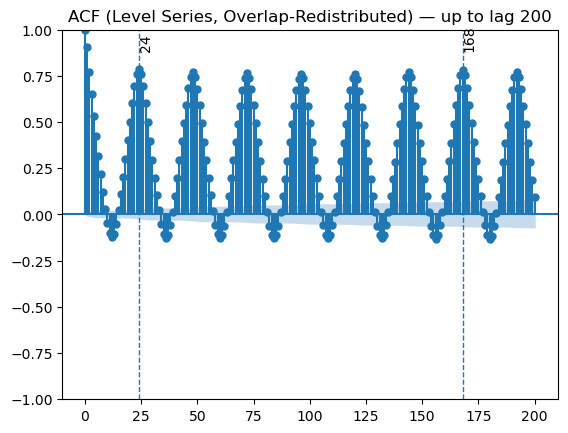

In [11]:
# STEP 7 — Plot ACF (level series) and inspect spikes at 24 and 168

fig = plot_acf(y, lags=NLAGS, alpha=0.05)
plt.title(f"ACF (Level Series, Overlap-Redistributed) — up to lag {NLAGS}")
plt.axvline(24, linestyle="--", linewidth=1)
plt.axvline(168, linestyle="--", linewidth=1)
plt.text(24, 0.9, "24", rotation=90)
plt.text(168, 0.9, "168", rotation=90)
plt.show()

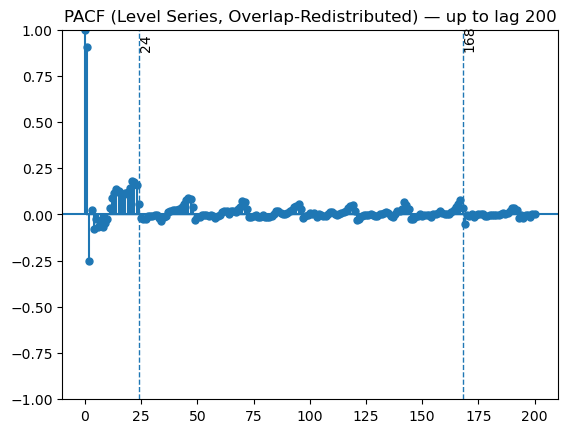

In [12]:
# STEP 8 — Plot PACF (level series) and inspect spikes at 24 and 168

fig = plot_pacf(y, lags=NLAGS, alpha=0.05, method="ywm")
plt.title(f"PACF (Level Series, Overlap-Redistributed) — up to lag {NLAGS}")
plt.axvline(24, linestyle="--", linewidth=1)
plt.axvline(168, linestyle="--", linewidth=1)
plt.text(24, 0.9, "24", rotation=90)
plt.text(168, 0.9, "168", rotation=90)
plt.show()

In [13]:
# STEP 9 — Numeric ACF/PACF spike check at lags 24 and 168

acf_vals = acf(y, nlags=NLAGS, fft=True)
pacf_vals = pacf(y, nlags=NLAGS, method="ywm")

spike_df = pd.DataFrame([{
    "lag": lag,
    "ACF": float(acf_vals[lag]),
    "PACF": float(pacf_vals[lag]),
} for lag in CHECK_LAGS if lag <= NLAGS])

print("ACF/PACF values at key seasonal lags:")
print(spike_df.to_string(index=False))

# Rough significance band (rule-of-thumb)
conf = 1.96 / np.sqrt(len(y))
print(f"\nApprox 95% band (rough): ±{conf:.6f}")

for lag in CHECK_LAGS:
    if lag <= NLAGS:
        a = acf_vals[lag]
        p = pacf_vals[lag]
        print(f"\nLag {lag}:")
        print(f"  ACF  = {a:.6f} -> {'SIGNIFICANT' if abs(a) > conf else 'not significant'}")
        print(f"  PACF = {p:.6f} -> {'SIGNIFICANT' if abs(p) > conf else 'not significant'}")

spike_df

ACF/PACF values at key seasonal lags:
 lag      ACF     PACF
  24 0.788359 0.058189
 168 0.783207 0.035349

Approx 95% band (rough): ±0.008601

Lag 24:
  ACF  = 0.788359 -> SIGNIFICANT
  PACF = 0.058189 -> SIGNIFICANT

Lag 168:
  ACF  = 0.783207 -> SIGNIFICANT
  PACF = 0.035349 -> SIGNIFICANT


,lag,ACF,PACF
0,24,0.788359,0.058189
1,168,0.783207,0.035349
